In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigD-Course-SparkRDD") \
    .master("spark://spark-master:7077") \
    .getOrCreate()
    
sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 23:05:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
spark

In [6]:
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import numpy as np

# Задание 1. Исследование структуры данных

## Загрузите данные из JSON-файла в RDD 

In [7]:
import json

flights_rdd = sc.textFile("/opt/spark/data/flights.json")

flights_parsed_rdd = flights_rdd.map(lambda x: json.loads(x))

flights_parsed_rdd = flights_parsed_rdd.cache()

## Исследуйте структуру данных (поля, типы значений) 

In [8]:
flights_parsed_rdd.count()

1000000

In [9]:
flights_parsed_rdd.take(2)

[{'FL_DATE': '2006-01-01',
  'DEP_DELAY': 5,
  'ARR_DELAY': 19,
  'AIR_TIME': 350,
  'DISTANCE': 2475,
  'DEP_TIME': 9.083333,
  'ARR_TIME': 12.483334},
 {'FL_DATE': '2006-01-02',
  'DEP_DELAY': 167,
  'ARR_DELAY': 216,
  'AIR_TIME': 343,
  'DISTANCE': 2475,
  'DEP_TIME': 11.783334,
  'ARR_TIME': 15.766666}]

In [10]:
first = flights_parsed_rdd.first()

for key, value in first.items():
    print(f"{key}: {type(value)}")

FL_DATE: <class 'str'>
DEP_DELAY: <class 'int'>
ARR_DELAY: <class 'int'>
AIR_TIME: <class 'int'>
DISTANCE: <class 'int'>
DEP_TIME: <class 'float'>
ARR_TIME: <class 'float'>


| Поле        | Тип   | Описание                                               |
| ----------- | ----- | ------------------------------------------------------------------- |
| `FL_DATE`   | str   | Дата рейса                           |
| `DEP_DELAY` | int   | Задержка вылета в минутах    |
| `ARR_DELAY` | int   | Задержка прибытия в минутах  |
| `AIR_TIME`  | int   | Время полёта в минутах                               |
| `DISTANCE`  | int   | Расстояние рейса в милях                            |
| `DEP_TIME`  | float | Время вылета                             |
| `ARR_TIME`  | float | Время прибытия                            |


## Определите диапазоны значений для числовых характеристик 

In [11]:
dep_delay_rdd = flights_parsed_rdd.map(lambda x: x['DEP_DELAY'])
min_dep_delay = dep_delay_rdd.min()
max_dep_delay = dep_delay_rdd.max()
print(f"DEP_DELAY: min = {min_dep_delay}, max = {max_dep_delay}")

DEP_DELAY: min = -1197, max = 1379


In [14]:
arr_delay_rdd = flights_parsed_rdd.map(lambda x: x['ARR_DELAY'])
min_arr_delay = arr_delay_rdd.min()
max_arr_delay = arr_delay_rdd.max()
print(f"ARR_DELAY: min = {min_arr_delay}, max = {max_arr_delay}")

ARR_DELAY: min = -197, max = 1374


In [15]:
air_time_rdd = flights_parsed_rdd.map(lambda x: x['AIR_TIME'])
min_air_time = air_time_rdd.min()
max_air_time = air_time_rdd.max()
print(f"AIR_TIME: min = {min_air_time}, max = {max_air_time}")

AIR_TIME: min = -2, max = 877


In [16]:
distance_rdd = flights_parsed_rdd.map(lambda x: x['DISTANCE'])
min_distance = distance_rdd.min()
max_distance = distance_rdd.max()
print(f"DISTANCE: min = {min_distance}, max = {max_distance}")

DISTANCE: min = 30, max = 4962


In [11]:
dep_time_rdd = flights_parsed_rdd.map(lambda x: x['DEP_TIME'])
min_dep_time = dep_time_rdd.min()
max_dep_time = dep_time_rdd.max()
print(f"DEP_TIME: min = {min_dep_time}, max = {max_dep_time}")

DEP_TIME: min = 0, max = 23.983334


In [17]:
arr_time_rdd = flights_parsed_rdd.map(lambda x: x['ARR_TIME'])
min_arr_time = arr_time_rdd.min()
max_arr_time = arr_time_rdd.max()
print(f"ARR_TIME: min = {min_arr_time}, max = {max_arr_time}")

ARR_TIME: min = 0, max = 23.983334


## Найдите аномалии в данных (отрицательные задержки, нулевые расстояния и т.д.)

In [18]:
numeric_fields = ['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME', 'DISTANCE', 'DEP_TIME', 'ARR_TIME']

anomaly_conditions = {
'AIR_TIME':  lambda x: x <= 0,     # нулевое или отрицательное время полёта  
'DISTANCE':  lambda x: x <= 0,     # нулевая или отрицательная дистанция  
'DEP_TIME':  lambda x: x < 0 or x > 24,  # неверное время вылета  
'ARR_TIME':  lambda x: x < 0 or x > 24   # неверное время прибытия  
}

anomalies_rdd = flights_parsed_rdd.filter(
    lambda x: any(cond(x[field]) for field, cond in anomaly_conditions.items())
).cache() 

anomalies_rdd.take(2)

[{'FL_DATE': '2006-01-04',
  'DEP_DELAY': 5,
  'ARR_DELAY': -15,
  'AIR_TIME': 0,
  'DISTANCE': 157,
  'DEP_TIME': 10.5,
  'ARR_TIME': 11.316667},
 {'FL_DATE': '2006-01-05',
  'DEP_DELAY': 0,
  'ARR_DELAY': -9,
  'AIR_TIME': 0,
  'DISTANCE': 413,
  'DEP_TIME': 8.85,
  'ARR_TIME': 10.483334}]

Для задержек может быть отрицательные значения(Раньше прилетел)

In [19]:
anomalies_count = anomalies_rdd.count()
print("Количество аномальных записей:", anomalies_count)

Количество аномальных записей: 10


# Задание 2. Анализ временных паттернов

## Сгруппируйте рейсы по времени вылета (утро/день/вечер/ночь)

In [20]:
def time_of_day(dep_time):
    if 5 <= dep_time < 12:
        return "Утро"
    elif 12 <= dep_time < 17:
        return "День"
    elif 17 <= dep_time < 21:
        return "Вечер"
    else:
        return "Ночь"

flights_rdd_tod = flights_parsed_rdd.map(lambda x: {**x, 'TIME_OF_DAY': time_of_day(x['DEP_TIME'])}).cache()

In [21]:
flights_rdd_tod.take(2)

[{'FL_DATE': '2006-01-01',
  'DEP_DELAY': 5,
  'ARR_DELAY': 19,
  'AIR_TIME': 350,
  'DISTANCE': 2475,
  'DEP_TIME': 9.083333,
  'ARR_TIME': 12.483334,
  'TIME_OF_DAY': 'Утро'},
 {'FL_DATE': '2006-01-02',
  'DEP_DELAY': 167,
  'ARR_DELAY': 216,
  'AIR_TIME': 343,
  'DISTANCE': 2475,
  'DEP_TIME': 11.783334,
  'ARR_TIME': 15.766666,
  'TIME_OF_DAY': 'Утро'}]

## Рассчитайте средние задержки вылета и прибытия для каждой группы 

In [22]:
tod_stats = flights_rdd_tod.map(lambda x: (x['TIME_OF_DAY'], (x['DEP_DELAY'], x['ARR_DELAY'], 1))) \
    .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2])) \
    .mapValues(lambda v: (v[0]/v[2], v[1]/v[2])).cache()  # Вычисление средних

print("Время, Задержка вылета, Задержка прибытия")
tod_stats.collect()

Время, Задержка вылета, Задержка прибытия


[('День', (8.855031782712508, 6.505021860616962)),
 ('Ночь', (27.72079887354945, 24.404097949406832)),
 ('Утро', (2.334964246341192, 0.3360768071527546)),
 ('Вечер', (14.104934974706355, 11.843500727327992))]

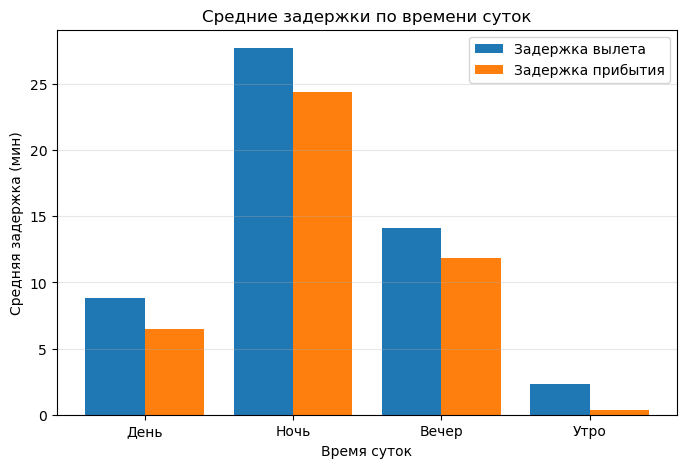

In [23]:
results = tod_stats.collect()

# Преобразуем списки
labels = [x[0] for x in results]
dep_delays = [x[1][0] for x in results]
arr_delays = [x[1][1] for x in results]

x = range(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x, dep_delays, width=0.4, label='Задержка вылета')
plt.bar([i + 0.4 for i in x], arr_delays, width=0.4, label='Задержка прибытия')

plt.xticks([i + 0.2 for i in x], labels)
plt.xlabel('Время суток')
plt.ylabel('Средняя задержка (мин)')
plt.title('Средние задержки по времени суток')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## Определите, в какие дни недели наблюдается наибольшая вариативность задержек 

In [26]:
def day_of_week(flight_date):
    return datetime.datetime.strptime(flight_date, "%Y-%m-%d").strftime('%A') 

flights_rdd_dow = flights_parsed_rdd.map(lambda x: {**x, 'DAY_OF_WEEK': day_of_week(x['FL_DATE'])}) # День недели

# Средние задержки по дням недели
dow_stats = flights_rdd_dow.map(lambda x: (x['DAY_OF_WEEK'], (x['DEP_DELAY'], x['ARR_DELAY'], 1))) \
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2])) \
    .mapValues(lambda v: (v[0]/v[2], v[1]/v[2])).cache()

print("День недели Задержка вылета, Задержка прибытия")
dow_stats.collect()

День недели Задержка вылета, Задержка прибытия


[('Sunday', (10.345628636069813, 7.97410983624219)),
 ('Thursday', (6.4434710289463855, 4.1226644488768915)),
 ('Saturday', (7.726567782466171, 5.121613872317845)),
 ('Tuesday', (6.565760838164205, 3.8816259974706133)),
 ('Monday', (12.006795664856165, 10.179497334540335)),
 ('Friday', (10.837042116126844, 9.265597387358094)),
 ('Wednesday', (6.09666498120342, 3.652325572874301))]

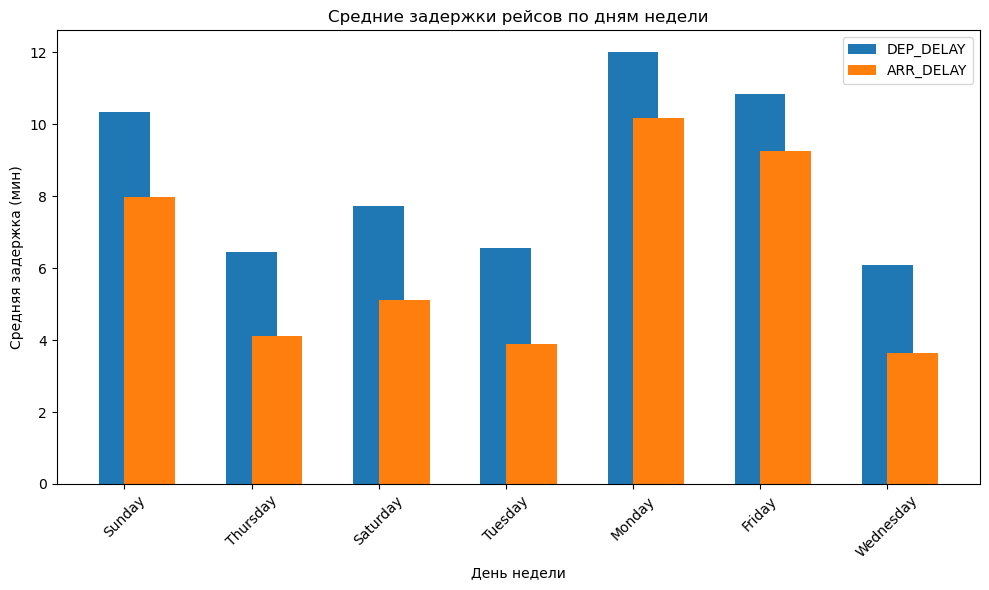

In [27]:
dow_data = dow_stats.collect()
days = [x[0] for x in dow_data]                
dep_delays = [x[1][0] for x in dow_data]      
arr_delays = [x[1][1] for x in dow_data]      

x = range(len(days)) 

plt.figure(figsize=(10,6))
plt.bar(x, dep_delays, width=0.4, label='DEP_DELAY', align='center')
plt.bar(x, arr_delays, width=0.4, label='ARR_DELAY', align='edge')
plt.xticks(x, days, rotation=45)
plt.ylabel("Средняя задержка (мин)")
plt.xlabel("День недели")
plt.title("Средние задержки рейсов по дням недели")
plt.legend()
plt.tight_layout()
plt.show()

## Выявите сезонные паттерны (если данные покрывают несколько месяцев)

In [28]:
flights_rdd_month = flights_parsed_rdd.map(lambda x: {**x, 'MONTH': int(x['FL_DATE'][5:7])})

month_stats = flights_rdd_month.map(lambda x: (x['MONTH'], (x['DEP_DELAY'], x['ARR_DELAY'], 1))) \
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2])) \
    .mapValues(lambda v: (v[0]/v[2], v[1]/v[2])).cache()

print("Месяц, Задержка вылета, Задержка прибытия")

month_stats.collect()

Месяц, Задержка вылета, Задержка прибытия


[(1, (8.05607493027906, 5.628670654061354)),
 (2, (9.440354060529927, 7.4245329983483375))]

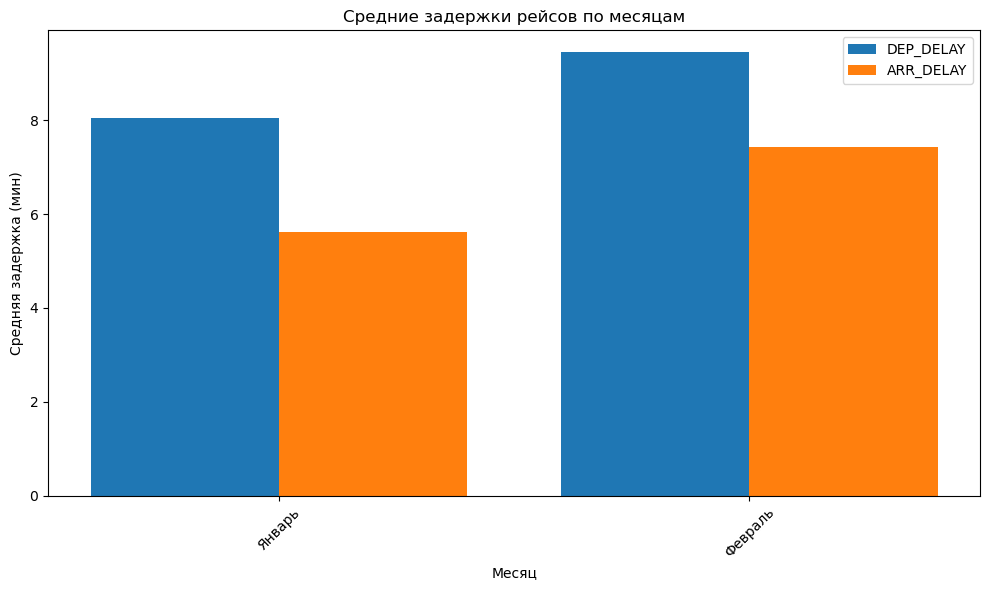

In [29]:
month_data = month_stats.collect()
months = [x[0] for x in month_data]
dep_delays = [x[1][0] for x in month_data]
arr_delays = [x[1][1] for x in month_data]

month_names = {1:"Январь", 2:"Февраль"}

x = range(len(months))

plt.figure(figsize=(10,6))
plt.bar([i-0.2 for i in x], dep_delays, width=0.4, label='DEP_DELAY')
plt.bar([i+0.2 for i in x], arr_delays, width=0.4, label='ARR_DELAY')
plt.xticks(x, [month_names[m] for m in months], rotation=45)
plt.ylabel("Средняя задержка (мин)")
plt.xlabel("Месяц")
plt.title("Средние задержки рейсов по месяцам")
plt.legend()
plt.tight_layout()
plt.show()

# Задание 3. Корреляционный анализ

## Исследуйте взаимосвязь между задержкой вылета и задержкой прибытия

In [32]:
dep_arr_rdd = flights_parsed_rdd.map(lambda x: (x['DEP_DELAY'], x['ARR_DELAY'])).cache()

sum_xy, sum_x2, sum_y2, sum_x, sum_y, n = dep_arr_rdd.map(lambda x: (x[0]*x[1], x[0]**2, x[1]**2, x[0], x[1], 1)) \
    .reduce(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4], a[5]+b[5]))

E_XY = sum_xy / n
E_X = sum_x / n
E_Y = sum_y / n
E_X2 = sum_x2 / n
E_Y2 = sum_y2 / n

corr_dep_arr = (E_XY - E_X*E_Y) / ((E_X2 - E_X**2)*(E_Y2 - E_Y**2))**0.5 # Делить на корень из дисперсии
print("Корреляция DEP_DELAY и ARR_DELAY:", corr_dep_arr)

Корреляция DEP_DELAY и ARR_DELAY: 0.9052460873068533


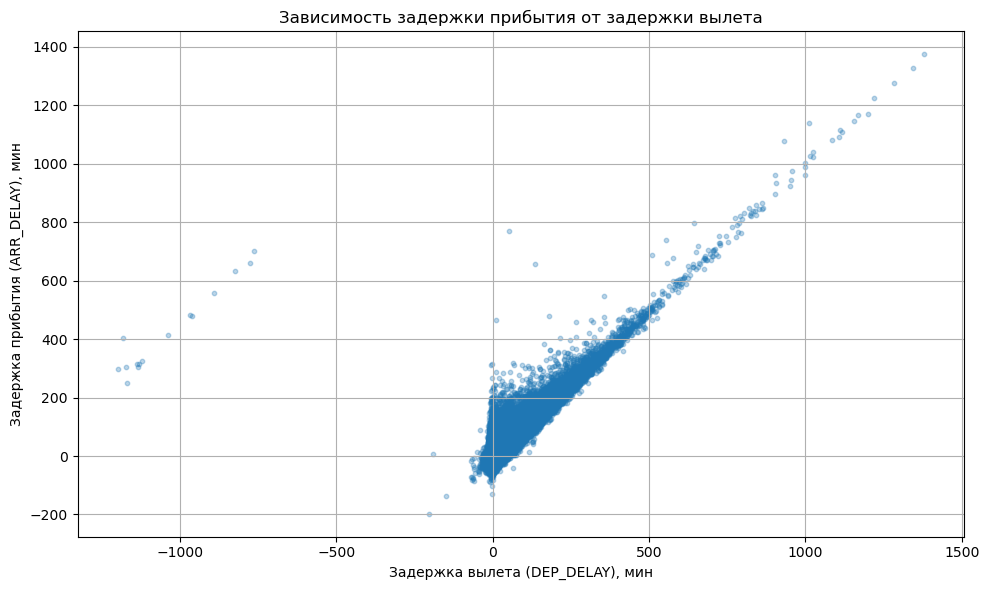

In [34]:
dep_arr_data = dep_arr_rdd.collect()
dep_delays = [x[0] for x in dep_arr_data]
arr_delays = [x[1] for x in dep_arr_data]

plt.figure(figsize=(10,6))
plt.scatter(dep_delays, arr_delays, alpha=0.3, s=10)
plt.xlabel("Задержка вылета (DEP_DELAY), мин")
plt.ylabel("Задержка прибытия (ARR_DELAY), мин")
plt.title("Зависимость задержки прибытия от задержки вылета")
plt.grid(True)
plt.tight_layout()
plt.show()

## Проанализируйте, как расстояние перелета влияет на время в пути

In [35]:
dist_airtime_rdd = flights_parsed_rdd.map(lambda x: (x['DISTANCE'], x['AIR_TIME'])).cache()

sum_xy, sum_x2, sum_y2, sum_x, sum_y, n = dist_airtime_rdd.map(
    lambda x: (x[0]*x[1], x[0]**2, x[1]**2, x[0], x[1], 1)
).reduce(
    lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4], a[5]+b[5])
)

E_XY = sum_xy / n
E_X = sum_x / n
E_Y = sum_y / n
E_X2 = sum_x2 / n
E_Y2 = sum_y2 / n

corr_dist_airtime = (E_XY - E_X*E_Y) / ((E_X2 - E_X**2)*(E_Y2 - E_Y**2))**0.5
print("Корреляция DISTANCE и AIR_TIME:", corr_dist_airtime)

Корреляция DISTANCE и AIR_TIME: 0.9759585972042416


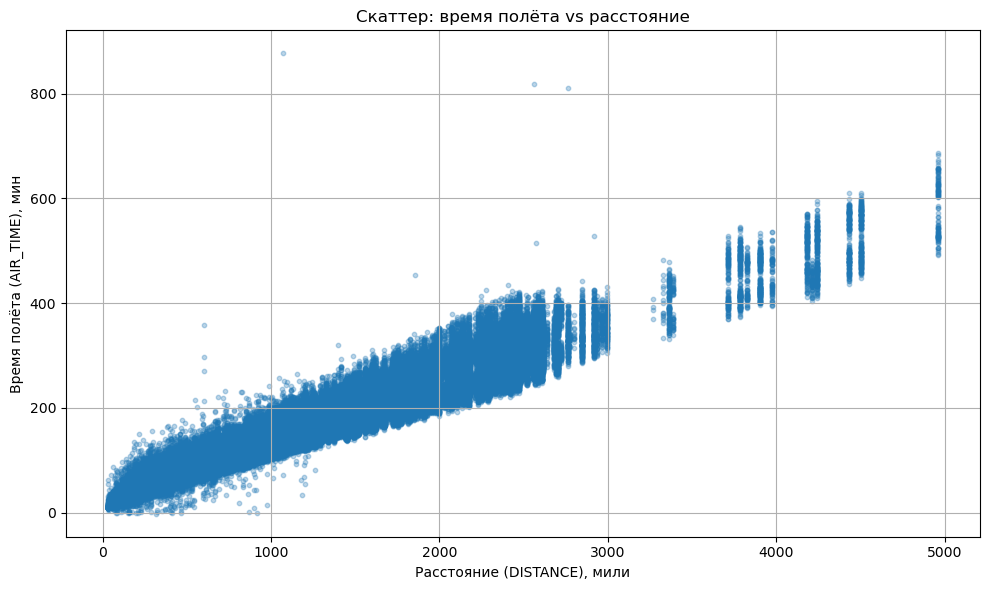

In [37]:
dist_airtime_data = dist_airtime_rdd.collect()
distances = [x[0] for x in dist_airtime_data]
air_times = [x[1] for x in dist_airtime_data]

plt.figure(figsize=(10,6))
plt.scatter(distances, air_times, alpha=0.3, s=10)
plt.xlabel("Расстояние (DISTANCE), мили")
plt.ylabel("Время полёта (AIR_TIME), мин")
plt.title("Скаттер: время полёта vs расстояние")
plt.grid(True)
plt.tight_layout()
plt.show()

## Определите, существует ли зависимость между временем вылета и величиной задержки

In [38]:
dep_time_delay_rdd = flights_parsed_rdd.map(lambda x: (x['DEP_TIME'], x['DEP_DELAY'])).cache()

sum_xy, sum_x2, sum_y2, sum_x, sum_y, n = dep_time_delay_rdd.map(
    lambda x: (x[0]*x[1], x[0]**2, x[1]**2, x[0], x[1], 1)
).reduce(
    lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4], a[5]+b[5])
)

E_XY = sum_xy / n
E_X = sum_x / n
E_Y = sum_y / n
E_X2 = sum_x2 / n
E_Y2 = sum_y2 / n

corr_dep_time_delay = (E_XY - E_X*E_Y) / ((E_X2 - E_X**2)*(E_Y2 - E_Y**2))**0.5
print("Корреляция DEP_TIME и DEP_DELAY:", corr_dep_time_delay)

Корреляция DEP_TIME и DEP_DELAY: 0.18700021852718393


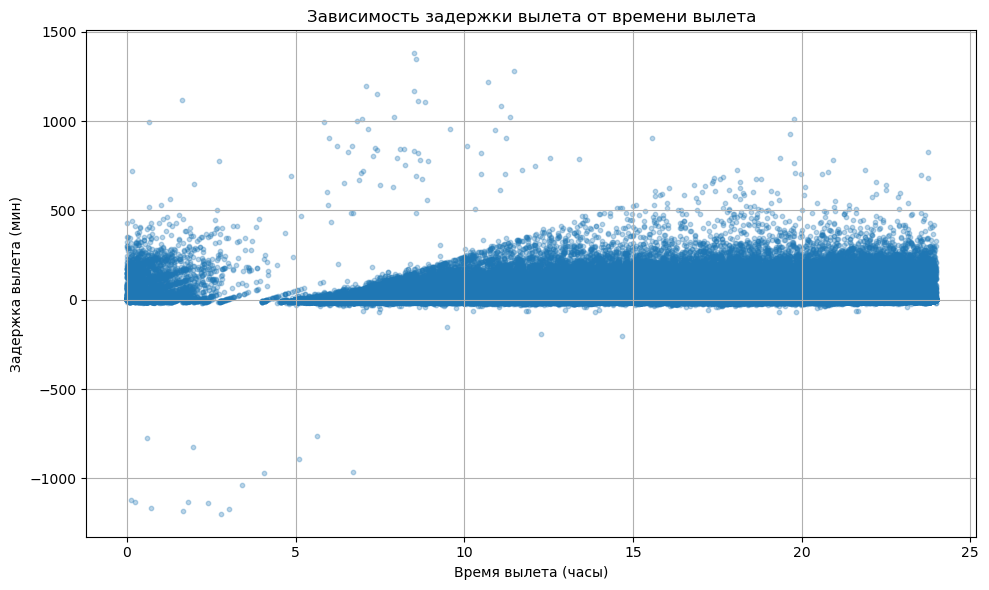

In [39]:
dep_time_delay_data = dep_time_delay_rdd.collect()
dep_times = [x[0] for x in dep_time_delay_data]
dep_delays = [x[1] for x in dep_time_delay_data]

plt.figure(figsize=(10,6))
plt.scatter(dep_times, dep_delays, alpha=0.3, s=10)
plt.xlabel("Время вылета (часы)")
plt.ylabel("Задержка вылета (мин)")
plt.title("Зависимость задержки вылета от времени вылета")
plt.grid(True)
plt.tight_layout()
plt.show()

Нет зависимости

## Рассчитайте коэффициент корреляции между ключевыми параметрами

In [40]:
def pearson_corr(rdd, col_x, col_y):
    vals_rdd = rdd.map(lambda x: (x[col_x], x[col_y]))
    
    sum_xy, sum_x2, sum_y2, sum_x, sum_y, n = vals_rdd.map(
        lambda x: (x[0]*x[1], x[0]**2, x[1]**2, x[0], x[1], 1)
    ).reduce(
        lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4], a[5]+b[5])
    )
    
    E_XY = sum_xy / n
    E_X = sum_x / n
    E_Y = sum_y / n
    E_X2 = sum_x2 / n
    E_Y2 = sum_y2 / n
    
    corr = (E_XY - E_X*E_Y) / ((E_X2 - E_X**2)*(E_Y2 - E_Y**2))**0.5
    return corr


In [41]:
columns = ['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME', 'DISTANCE', 'DEP_TIME', 'ARR_TIME']

corr_matrix = []
for i in range(len(columns)):
    row = []
    for j in range(len(columns)):
        row.append(pearson_corr(flights_parsed_rdd, columns[i], columns[j]))
    corr_matrix.append(row)

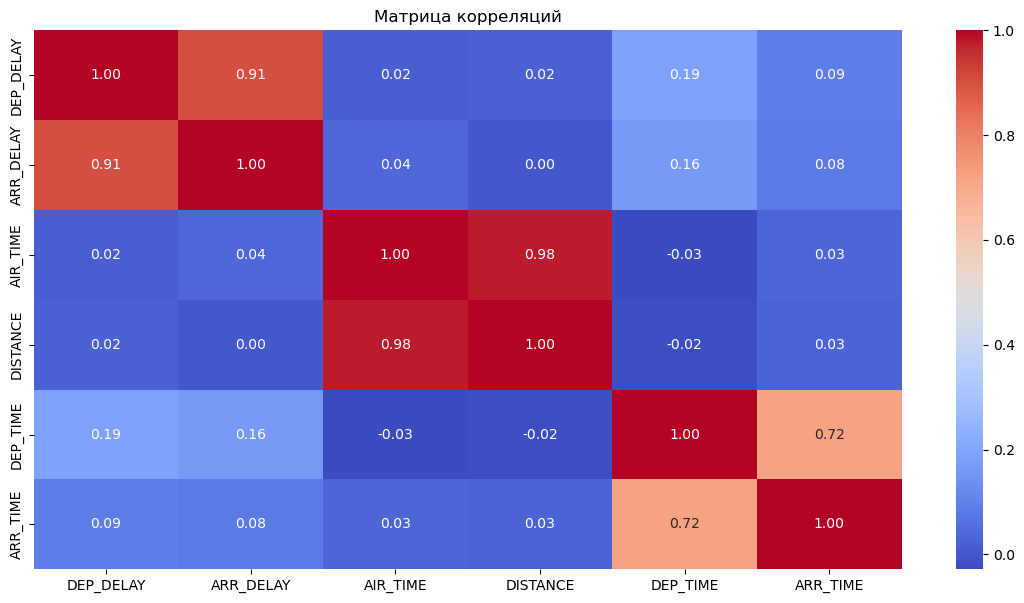

In [42]:
plt.figure(figsize=(14,7))
sns.heatmap(np.array(corr_matrix), xticklabels=columns, yticklabels=columns, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

# Задание 4. Классификация рейсов по "пунктуальности"

## Разработайте критерии классификации рейсов (на основе задержек)

In [44]:
def classify_flight(flight):
    if -15 <= flight['DEP_DELAY'] <= 15 and -15 <= flight['ARR_DELAY'] <= 15:
        return 'Пунктуальный'
    else:
        return 'Проблемный' # Разница не больше 15 минут

In [46]:
flights_rdd_classified = flights_parsed_rdd.map(lambda x: {**x, 'STATUS': classify_flight(x)}).cache()

flights_rdd_classified.take(2)

[{'FL_DATE': '2006-01-01',
  'DEP_DELAY': 5,
  'ARR_DELAY': 19,
  'AIR_TIME': 350,
  'DISTANCE': 2475,
  'DEP_TIME': 9.083333,
  'ARR_TIME': 12.483334,
  'STATUS': 'Проблемный'},
 {'FL_DATE': '2006-01-02',
  'DEP_DELAY': 167,
  'ARR_DELAY': 216,
  'AIR_TIME': 343,
  'DISTANCE': 2475,
  'DEP_TIME': 11.783334,
  'ARR_TIME': 15.766666,
  'STATUS': 'Проблемный'}]

In [47]:
status_counts = flights_rdd_classified.map(lambda x: (x['STATUS'], 1)) \
                                      .reduceByKey(lambda a, b: a + b)
status_counts.collect()

[('Проблемный', 354218), ('Пунктуальный', 645782)]

## Создайте категории: "досрочные", "пунктуальные", "незначительные задержки", "существенные задержки"

In [48]:
def classify_flight_detailed(flight):
    dep = flight['DEP_DELAY']
    arr = flight['ARR_DELAY']
    
    if dep < -5 and arr < -5:
        return 'Досрочные'
    elif -5 <= dep <= 5 and -5 <= arr <= 5:
        return 'Пунктуальные'
    elif (5 < dep <= 60) or (5 < arr <= 60):
        return 'Незначительные задержки'
    else: 
        return 'Существенные задержки'

In [51]:
flights_rdd_classified = flights_parsed_rdd.map(
    lambda x: {**x, 'STATUS_DETAILED': classify_flight_detailed(x)}
).cache()

flights_rdd_classified.take(2)

[{'FL_DATE': '2006-01-01',
  'DEP_DELAY': 5,
  'ARR_DELAY': 19,
  'AIR_TIME': 350,
  'DISTANCE': 2475,
  'DEP_TIME': 9.083333,
  'ARR_TIME': 12.483334,
  'STATUS_DETAILED': 'Незначительные задержки'},
 {'FL_DATE': '2006-01-02',
  'DEP_DELAY': 167,
  'ARR_DELAY': 216,
  'AIR_TIME': 343,
  'DISTANCE': 2475,
  'DEP_TIME': 11.783334,
  'ARR_TIME': 15.766666,
  'STATUS_DETAILED': 'Существенные задержки'}]

In [53]:
status_counts = flights_rdd_classified.map(lambda x: (x['STATUS_DETAILED'], 1)) \
                                      .reduceByKey(lambda a, b: a + b).cache()
status_counts.collect()

[('Пунктуальные', 213036),
 ('Досрочные', 102959),
 ('Незначительные задержки', 337572),
 ('Существенные задержки', 346433)]

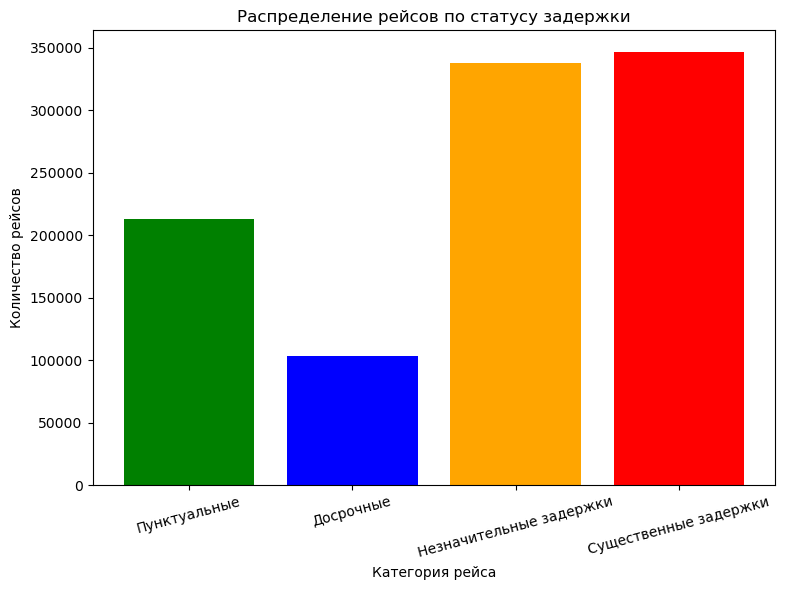

In [54]:
status_data = status_counts.collect()
categories = [x[0] for x in status_data]
counts = [x[1] for x in status_data]

plt.figure(figsize=(8,6))
plt.bar(categories, counts, color=['green', 'blue', 'orange', 'red'])
plt.xlabel("Категория рейса")
plt.ylabel("Количество рейсов")
plt.title("Распределение рейсов по статусу задержки")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Определите характеристики наиболее "пунктуальных" рейсов

In [55]:
punctual_rdd = flights_rdd_classified.filter(lambda x: x['STATUS_DETAILED'] == 'Пунктуальные')

In [56]:
stats = punctual_rdd.map(
    lambda x: (x['DEP_DELAY'], x['ARR_DELAY'], x['AIR_TIME'], x['DISTANCE'], x['DEP_TIME'], x['ARR_TIME'], 1)
).reduce(
    lambda a, b: (
        a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4], a[5]+b[5], a[6]+b[6]
    )
)

n = stats[6]
avg_dep_delay = stats[0]/n
avg_arr_delay = stats[1]/n
avg_air_time = stats[2]/n
avg_distance = stats[3]/n
avg_dep_time = stats[4]/n
avg_arr_time = stats[5]/n

print("Средние характеристики пунктуальных рейсов:")
print(f"DEP_DELAY: {avg_dep_delay:.2f} мин")
print(f"ARR_DELAY: {avg_arr_delay:.2f} мин")
print(f"AIR_TIME: {avg_air_time:.2f} мин")
print(f"DISTANCE: {avg_distance:.2f} миль")
print(f"DEP_TIME: {avg_dep_time:.2f} час")
print(f"ARR_TIME: {avg_arr_time:.2f} час")

Средние характеристики пунктуальных рейсов:
DEP_DELAY: -0.93 мин
ARR_DELAY: -0.83 мин
AIR_TIME: 95.00 мин
DISTANCE: 643.49 миль
DEP_TIME: 13.11 час
ARR_TIME: 14.68 час


Средние задержки пунктуальных рейсов близки к 0

# Задание 5. Пространственный анализ

## Сгруппируйте рейсы по дистанциям (короткие/средние/длинные)

In [57]:
def classify_distance(flight):
    dist = flight['DISTANCE']
    if dist <= 500:
        return 'Короткие'
    elif dist <= 1500:
        return 'Средние'
    else:
        return 'Длинные'

In [58]:
flights_rdd_distance = flights_parsed_rdd.map(
    lambda x: {**x, 'DISTANCE_CATEGORY': classify_distance(x)}
)

flights_rdd_distance.take(2)

[{'FL_DATE': '2006-01-01',
  'DEP_DELAY': 5,
  'ARR_DELAY': 19,
  'AIR_TIME': 350,
  'DISTANCE': 2475,
  'DEP_TIME': 9.083333,
  'ARR_TIME': 12.483334,
  'DISTANCE_CATEGORY': 'Длинные'},
 {'FL_DATE': '2006-01-02',
  'DEP_DELAY': 167,
  'ARR_DELAY': 216,
  'AIR_TIME': 343,
  'DISTANCE': 2475,
  'DEP_TIME': 11.783334,
  'ARR_TIME': 15.766666,
  'DISTANCE_CATEGORY': 'Длинные'}]

In [60]:
distance_counts = flights_rdd_distance.map(lambda x: (x['DISTANCE_CATEGORY'], 1)) \
                                      .reduceByKey(lambda a, b: a + b).cache()
distance_counts.collect()

[('Длинные', 108546), ('Короткие', 429534), ('Средние', 461920)]

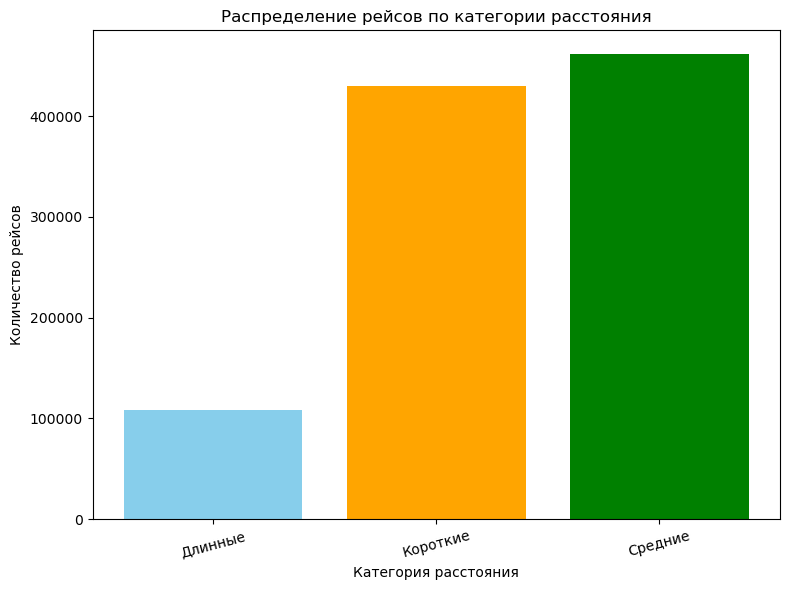

In [61]:
distance_data = distance_counts.collect()
categories = [x[0] for x in distance_data]
counts = [x[1] for x in distance_data]

plt.figure(figsize=(8,6))
plt.bar(categories, counts, color=['skyblue', 'orange', 'green'])
plt.xlabel("Категория расстояния")
plt.ylabel("Количество рейсов")
plt.title("Распределение рейсов по категории расстояния")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Сравните характеристики задержек для разных групп расстояний

In [62]:
distance_stats = flights_rdd_distance.map(
    lambda x: (x['DISTANCE_CATEGORY'], (x['DEP_DELAY'], x['ARR_DELAY'], x['DEP_TIME'], x['ARR_TIME'], 1))
).reduceByKey(
    lambda a, b: (a[0]+b[0], a[1]+b[1], a[2]+b[2], a[3]+b[3], a[4]+b[4])
).mapValues(
    lambda v: (
        v[0]/v[4],  # средний DEP_DELAY
        v[1]/v[4],  # средний ARR_DELAY
        v[2]/v[4],  # средний DEP_TIME
        v[3]/v[4]   # средний ARR_TIME
    )
).cache()

print("Поездка, Задержка вылета, Задержка прибытия, Время вылета, Время прибытия")
distance_stats.collect()

Поездка, Задержка вылета, Задержка прибытия, Время вылета, Время прибытия


[('Длинные',
  (9.641838483223703,
   6.050807952388849,
   13.507581420592835,
   15.185632667342986)),
 ('Короткие',
  (7.601824302616324,
   5.881937169118161,
   13.834978136591031,
   14.870321867573628)),
 ('Средние',
  (9.394072566678213,
   6.965221250432975,
   13.450749372170817,
   15.36834224475036))]

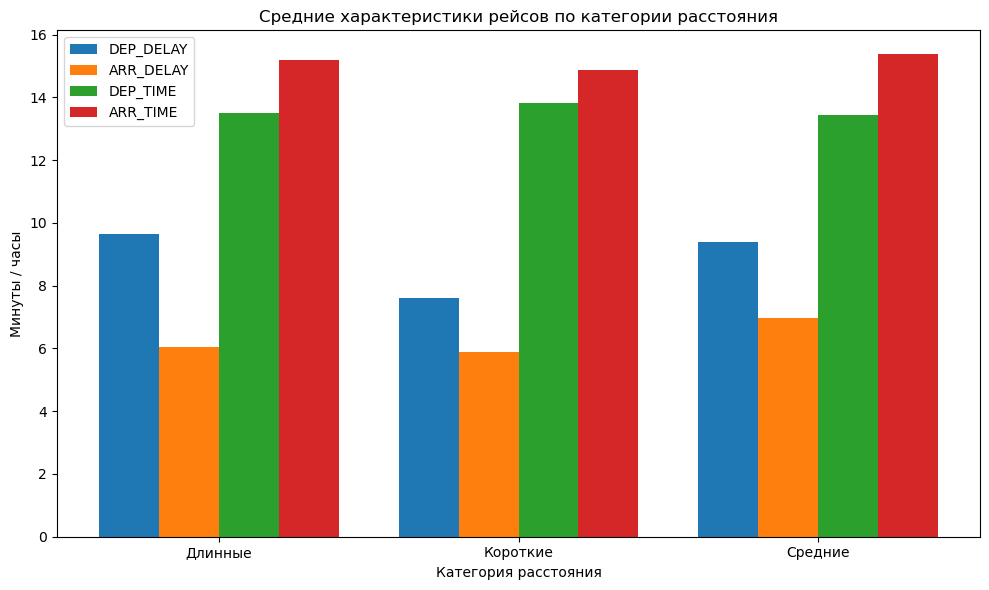

In [63]:
distance_stats_data = distance_stats.collect()
categories = [x[0] for x in distance_stats_data]
dep_delays = [x[1][0] for x in distance_stats_data]
arr_delays = [x[1][1] for x in distance_stats_data]
dep_times = [x[1][2] for x in distance_stats_data]
arr_times = [x[1][3] for x in distance_stats_data]

x = np.arange(len(categories))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - width*1.5, dep_delays, width, label='DEP_DELAY')
plt.bar(x - width/2, arr_delays, width, label='ARR_DELAY')
plt.bar(x + width/2, dep_times, width, label='DEP_TIME')
plt.bar(x + width*1.5, arr_times, width, label='ARR_TIME')

plt.xticks(x, categories)
plt.xlabel("Категория расстояния")
plt.ylabel("Минуты / часы")
plt.title("Средние характеристики рейсов по категории расстояния")
plt.legend()
plt.tight_layout()
plt.show()

## Определите оптимальную скорость для каждой категории расстояний

In [64]:
flights_rdd_speed = flights_rdd_distance.map(
    lambda x: {**x, 'SPEED': x['DISTANCE'] / (x['AIR_TIME'] / 60) if x['AIR_TIME'] > 0 else None}
)

In [69]:
speed_stats = flights_rdd_speed.map(
    lambda x: (x['DISTANCE_CATEGORY'], (x['SPEED'], 1)) if x['SPEED'] is not None else ('IGNORE', (0,0))
).filter(lambda x: x[0] != 'IGNORE') \
 .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1])) \
 .mapValues(lambda v: v[0]/v[1]).cache()

print("Поездка, скорость")
speed_stats.collect()

Поездка, скорость


[('Длинные', 479.38045616292084),
 ('Короткие', 333.0738826591886),
 ('Средние', 427.36407272691315)]

## Выявите аномалии - рейсы с непропорциональным временем в пути для их расстояния

In [70]:
speed_rdd = flights_rdd_speed.filter(lambda x: x['SPEED'] is not None) \
                             .map(lambda x: (x['DISTANCE_CATEGORY'], x['SPEED']))

Работаем не со временем и расстоянием напрямую, а со скоростью, которая вычисляется из них двоих

In [71]:
quantile_bounds = {}

for category in ['Короткие', 'Средние', 'Длинные']:
    speeds = speed_rdd.filter(lambda x: x[0]==category).map(lambda x: x[1]).collect()
    speeds.sort()
    n = len(speeds)
    
    Q1 = speeds[int(0.25*n)]
    Q3 = speeds[int(0.75*n)]
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    quantile_bounds[category] = (lower, upper)

In [49]:
quantile_bounds

{'Короткие': (159.86545682102627, 509.7277847309137),
 'Средние': (283.40778416629803, 570.6612118531624),
 'Длинные': (291.50039359748104, 667.3051692469166)}

In [72]:
anomalies_rdd = flights_rdd_speed.filter(
    lambda x: x['SPEED'] is not None and (
        x['SPEED'] < quantile_bounds[x['DISTANCE_CATEGORY']][0] or
        x['SPEED'] > quantile_bounds[x['DISTANCE_CATEGORY']][1]
    )
).cache()

anomalies_rdd.take(2)

[{'FL_DATE': '2006-01-20',
  'DEP_DELAY': 37,
  'ARR_DELAY': 69,
  'AIR_TIME': 73,
  'DISTANCE': 802,
  'DEP_TIME': 18.616667,
  'ARR_TIME': 21.666666,
  'DISTANCE_CATEGORY': 'Средние',
  'SPEED': 659.1780821917808},
 {'FL_DATE': '2006-01-19',
  'DEP_DELAY': -10,
  'ARR_DELAY': 49,
  'AIR_TIME': 157,
  'DISTANCE': 733,
  'DEP_TIME': 8.833333,
  'ARR_TIME': 11.516666,
  'DISTANCE_CATEGORY': 'Средние',
  'SPEED': 280.12738853503186}]

In [74]:
anomalies_rdd.count()

6142

In [75]:
spark.stop()